In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression
import Feature_Engineering as FE
import matplotlib.pyplot as plt

c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\ProgramData\Minic

In [2]:
data = FE.data
data_reg = data[(data['INGRESO'] == 1) & (data["PROP"].notna())]
y_reg = data_reg['logP47T']
excluir_cols = {'logP47T', 'Q','INGRESO', 'CODUSU', 'P47T', 'P21', 'T_VI', 'V12_M', 'V2_M', 'V3_M', 'V5_M', 'TOT_P12', 'PP08D1', 
                'logP21', 'logT_VI', 'logV12_M', 'logV2_M', 'logV3_M', 'logV5_M', 'logTOT_P12', 'logPP08D1','ANO4','TRIMESTRE','INGRESO_NLB','INGRESO_JUB','INGRESO_SBS'}
X_reg = data_reg.drop(columns=excluir_cols)


In [3]:
target_col = "logP47T"

X = X_reg
y = data_reg[target_col].values

In [ ]:
#Modelos con hiperparámetros
models = {
    "HistGradient": HistGradientBoostingRegressor(
        l2_regularization=0,
        learning_rate=0.1,
        max_iter=200,
        max_leaf_nodes=400,
        min_samples_leaf=15,
        random_state=42
    ),
    "Ridge": Ridge(
        alpha=5,
        fit_intercept=True,
        random_state=42
    ),
    "LinearRegression": LinearRegression(
        fit_intercept=True
    ),
        "MLP": MLPRegressor(
        batch_size=64,
        hidden_layer_sizes=(64, 64, 32),
        max_iter=100,
        random_state=42
    )
}

In [ ]:
#Preprocesamiento según columnas

def make_preprocessor(X: pd.DataFrame, scale_numeric: bool = True):

    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    
    if scale_numeric:
        numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
        ])
    else:
        numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
        ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop = 'first'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ],
        remainder="drop"
    )

    return preprocessor

In [6]:
#Evaluacion con CV
def cv_r2_score(model, X: pd.DataFrame, y, cv, scale_numeric: bool):
    preprocessor = make_preprocessor(X, scale_numeric=scale_numeric)
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("reg", model)
    ])

    scores = cross_val_score(pipe, X, y, scoring="r2", cv=cv, n_jobs=-1)
    return float(np.mean(scores)), float(np.std(scores))

In [7]:
def forward_select_steps(
    X: pd.DataFrame, y, model, model_name: str,
    max_k: int = 6,
    cv_splits: int = 5,
    random_state: int = 42
):
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    scale_numeric = model_name in ["MLP", "Ridge", "LinearRegression"]

    features = list(X.columns)

    remaining = features.copy()
    selected = []

    best_by_k = {}
    history = [] 

    for k in range(1, max_k + 1):
        print("Modelo:", model_name, "Numero columnas:", k)
        step_results = []
        for f in remaining:
            cols = selected + [f]
            mean_r2, std_r2 = cv_r2_score(model, X[cols], y, cv=cv, scale_numeric=scale_numeric)
            step_results.append((tuple(cols), mean_r2, std_r2, f))

        step_results.sort(key=lambda t: t[1], reverse=True)

        best_cols, best_mean, best_std, best_new_feature = step_results[0]

        selected.append(best_new_feature)
        remaining.remove(best_new_feature)

        best_by_k[k] = {"features": best_cols, "r2_mean": best_mean, "r2_std": best_std}

        history.append({
            "k": k,
            "selected": tuple(selected),
            "mean_r2": best_mean,
            "std_r2": best_std
        })

    out = {"model": model_name}

    for k, info in best_by_k.items():
        out[f"best_{k}_features"] = info["features"]
        out[f"best_{k}_r2_mean"] = info["r2_mean"]
        out[f"best_{k}_r2_std"] = info["r2_std"]

    return out, history, tuple(selected)

In [ ]:
def build_feature_labels(selected_order):
    labels = []
    for i, feat in enumerate(selected_order):
        if i == 0:
            labels.append(feat)
        else:
            labels.append(f"+ {feat}")
    return labels

In [ ]:
def run_all_models_forward_selection_with_plots(
    X: pd.DataFrame, y,
    max_k: int | None = 6,
    cv_splits: int = 5,
    random_state: int = 42
):

    summary_rows = []
    detailed = {}
    results = {}

    # Subplots por modelo (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    ax_list = axes.ravel()

    for idx, (name, model) in enumerate(models.items()):
        out, history, selected_order = forward_select_steps(
            X, y, model, model_name=name,
            max_k=max_k, cv_splits=cv_splits,
            random_state=random_state
        )

        x_labels = build_feature_labels(selected_order)

        detailed[name] = out
        results[name] = {"selected_order": selected_order, "history": history}

        row = {"Model": name}
        for k in range(1, max_k + 1):
            row[f"Best {k} features"] = out.get(f"best_{k}_features", None)
            row[f"R2 mean ({k})"] = out.get(f"best_{k}_r2_mean", np.nan)
            row[f"R2 std ({k})"] = out.get(f"best_{k}_r2_std", np.nan)

        summary_rows.append(row)

        ks = [h["k"] for h in history]
        r2_means = [h["mean_r2"] for h in history]
        r2_stds = [h["std_r2"] for h in history]

        ax = ax_list[idx]
        ax.errorbar(ks, r2_means, yerr=r2_stds, fmt="-o",
                    ecolor="gray", elinewidth=1, capsize=3, markersize=4)
        ax.set_title(name, fontsize=11)
    
        ax.set_xticks(ks)
        ax.set_xticklabels(x_labels, rotation=45, ha="right")
        ax.set_xlabel("Feature agregada")

        ax.set_ylabel("R² medio (CV)")
        ax.grid(True, alpha=0.3)

        best_idx = int(np.argmax(r2_means))
        ax.scatter(ks[best_idx], r2_means[best_idx], color="tab:red",
                   zorder=3, label="Mejor R²")
        ax.legend()

    fig.suptitle("Evolución del R² (CV) vs número de columnas seleccionadas", fontsize=14)
    plt.savefig("forward_selection_all_models.png", dpi=140)
    plt.show()


    summary_df = pd.DataFrame(summary_rows)

    return summary_df, detailed, results

Modelo: HistGradient Numero columnas: 1
Modelo: HistGradient Numero columnas: 2
Modelo: HistGradient Numero columnas: 3
Modelo: HistGradient Numero columnas: 4
Modelo: HistGradient Numero columnas: 5
Modelo: HistGradient Numero columnas: 6
Modelo: Ridge Numero columnas: 1
Modelo: Ridge Numero columnas: 2
Modelo: Ridge Numero columnas: 3
Modelo: Ridge Numero columnas: 4
Modelo: Ridge Numero columnas: 5
Modelo: Ridge Numero columnas: 6
Modelo: LinearRegression Numero columnas: 1
Modelo: LinearRegression Numero columnas: 2
Modelo: LinearRegression Numero columnas: 3
Modelo: LinearRegression Numero columnas: 4
Modelo: LinearRegression Numero columnas: 5
Modelo: LinearRegression Numero columnas: 6
Modelo: MLP Numero columnas: 1
Modelo: MLP Numero columnas: 2
Modelo: MLP Numero columnas: 3
Modelo: MLP Numero columnas: 4
Modelo: MLP Numero columnas: 5
Modelo: MLP Numero columnas: 6


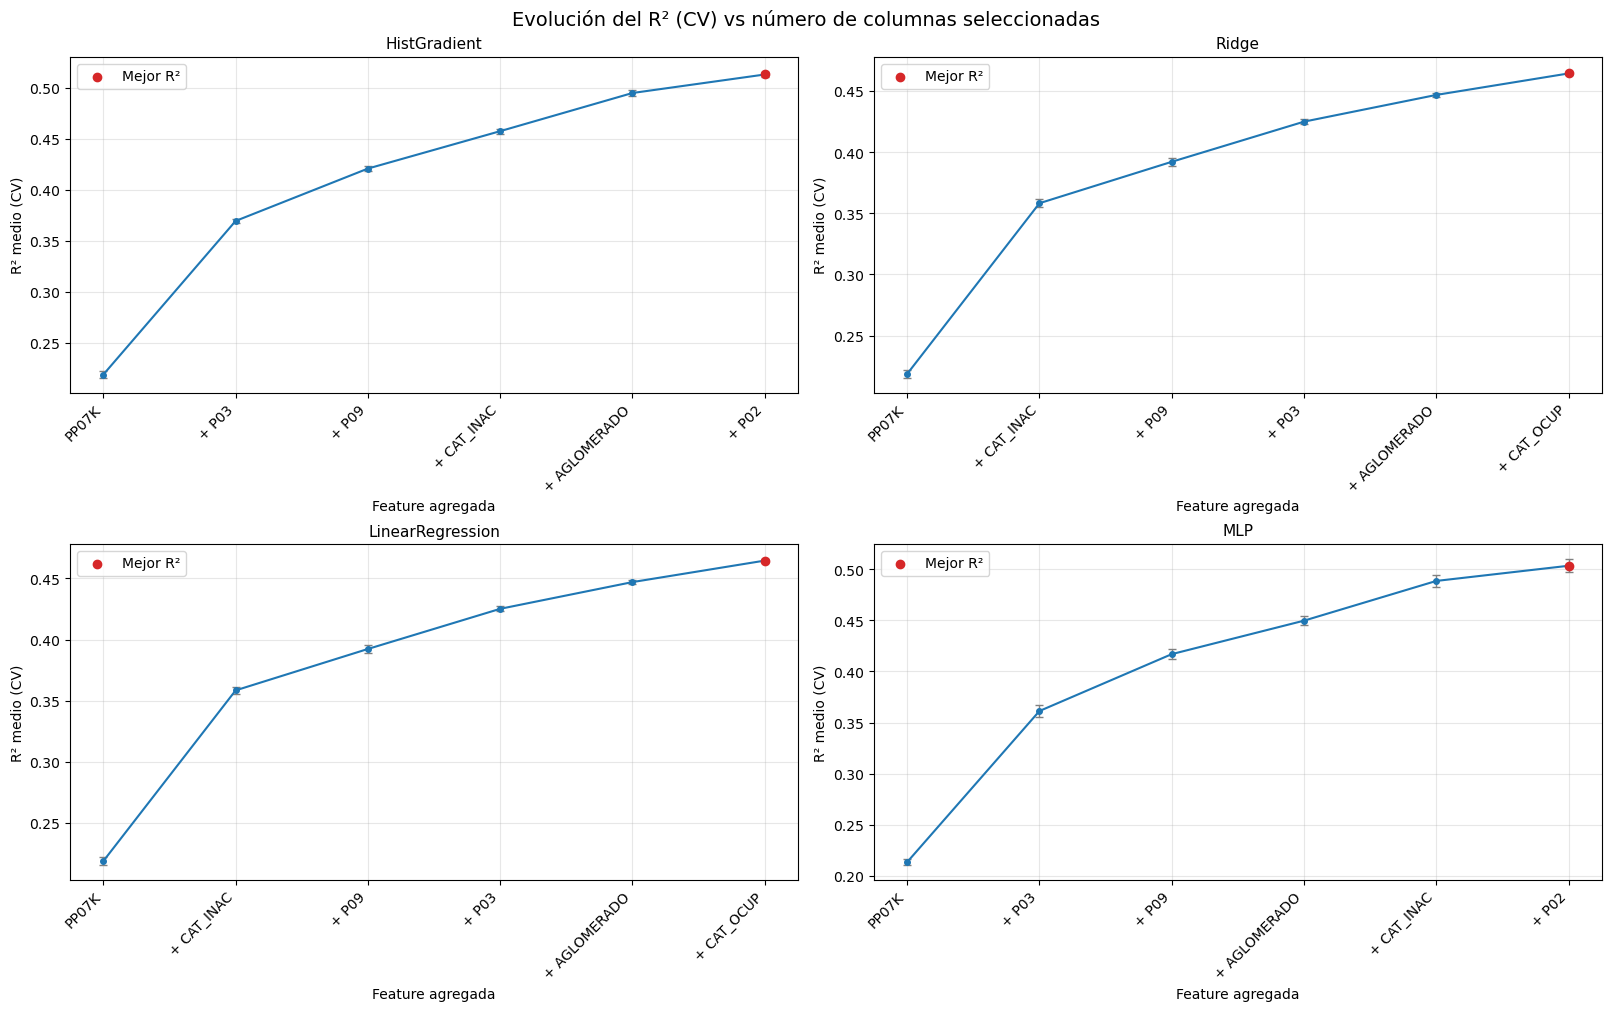

              Model Best 1 features  R2 mean (1)  R2 std (1)  \
0      HistGradient        (PP07K,)     0.218576    0.003175   
1             Ridge        (PP07K,)     0.218580    0.003180   
2  LinearRegression        (PP07K,)     0.218580    0.003181   
3               MLP        (PP07K,)     0.213379    0.002816   

     Best 2 features  R2 mean (2)  R2 std (2)         Best 3 features  \
0       (PP07K, P03)     0.369486    0.002385       (PP07K, P03, P09)   
1  (PP07K, CAT_INAC)     0.358364    0.003171  (PP07K, CAT_INAC, P09)   
2  (PP07K, CAT_INAC)     0.358364    0.003172  (PP07K, CAT_INAC, P09)   
3       (PP07K, P03)     0.361318    0.005600       (PP07K, P03, P09)   

   R2 mean (3)  R2 std (3)                Best 4 features  R2 mean (4)  \
0     0.420939    0.002209    (PP07K, P03, P09, CAT_INAC)     0.457696   
1     0.392278    0.003127    (PP07K, CAT_INAC, P09, P03)     0.425154   
2     0.392278    0.003128    (PP07K, CAT_INAC, P09, P03)     0.425154   
3     0.416986   

In [10]:
max_k = 6
cv_splits = 5    
seed = 42

summary_df, detailed, results = run_all_models_forward_selection_with_plots(
    X, y,
    max_k=max_k,
    cv_splits=cv_splits,
    random_state=seed
)
print(summary_df)
print(detailed)
print(results)